In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('/Users/prernamalhotra/CRIME/crime-analysis-prediction/data/crime_data_cleaned.csv')
print(f"Loaded {df.shape[0]:,} records")
print(df['Crime Category'].value_counts())

Loaded 1,419,631 records
Crime Category
Property        618956
Violent         419007
Other           216317
Drug            131214
Public Order     34137
Name: count, dtype: int64


In [10]:
feature_cols = ['Hour', 'Day', 'Month', 'DayOfWeek', 'Year',
                'Latitude', 'Longitude', 'Arrest', 'Domestic', 'District']

feature_cols = [c for c in feature_cols if c in df.columns]

for col in ['Arrest', 'Domestic']:
    if df[col].dtype == object:
        df[col] = df[col].map({'True':1,'False':0,'true':1,'false':0}).fillna(0)
    df[col] = df[col].astype(int)

df['District'] = pd.to_numeric(df['District'], errors='coerce').fillna(0)

X = df[feature_cols].fillna(0)
y = df['Crime Category']

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features: ['Hour', 'Day', 'Month', 'DayOfWeek', 'Year', 'Latitude', 'Longitude', 'Arrest', 'Domestic', 'District']
X shape: (1419631, 10)
Target distribution:
Crime Category
Property        618956
Violent         419007
Other           216317
Drug            131214
Public Order     34137
Name: count, dtype: int64


In [11]:
# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

Label encoding:
  0 → Drug
  1 → Other
  2 → Property
  3 → Public Order
  4 → Violent

Training set: 1,135,704 samples
Testing set:  283,927 samples


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"  ✓ {name}: Accuracy = {acc*100:.2f}%")

print("\n✅ All models trained!")

Training Logistic Regression...
  ✓ Logistic Regression: Accuracy = 58.00%
Training Decision Tree...
  ✓ Decision Tree: Accuracy = 59.51%
Training Random Forest...
  ✓ Random Forest: Accuracy = 59.96%

✅ All models trained!


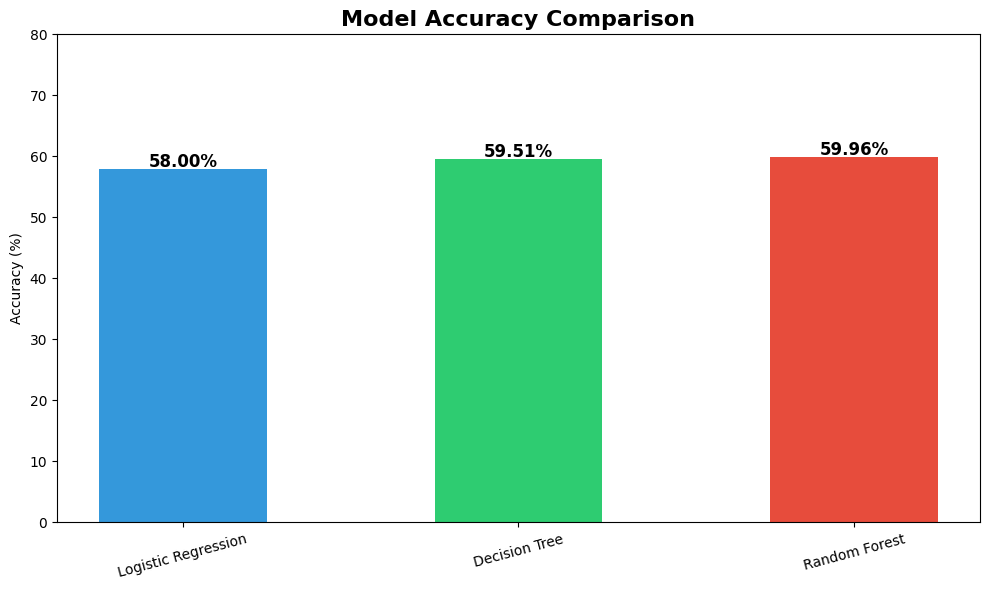

Chart saved!


In [13]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(model_names, [a*100 for a in accuracies], color=colors, width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 80)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/08_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Best Model: Random Forest
Accuracy: 59.96%

Classification Report:
              precision    recall  f1-score   support

        Drug       0.56      0.81      0.66     26243
       Other       0.41      0.15      0.22     43263
    Property       0.63      0.83      0.72    123792
Public Order       0.23      0.04      0.07      6827
     Violent       0.59      0.47      0.53     83802

    accuracy                           0.60    283927
   macro avg       0.48      0.46      0.44    283927
weighted avg       0.57      0.60      0.56    283927



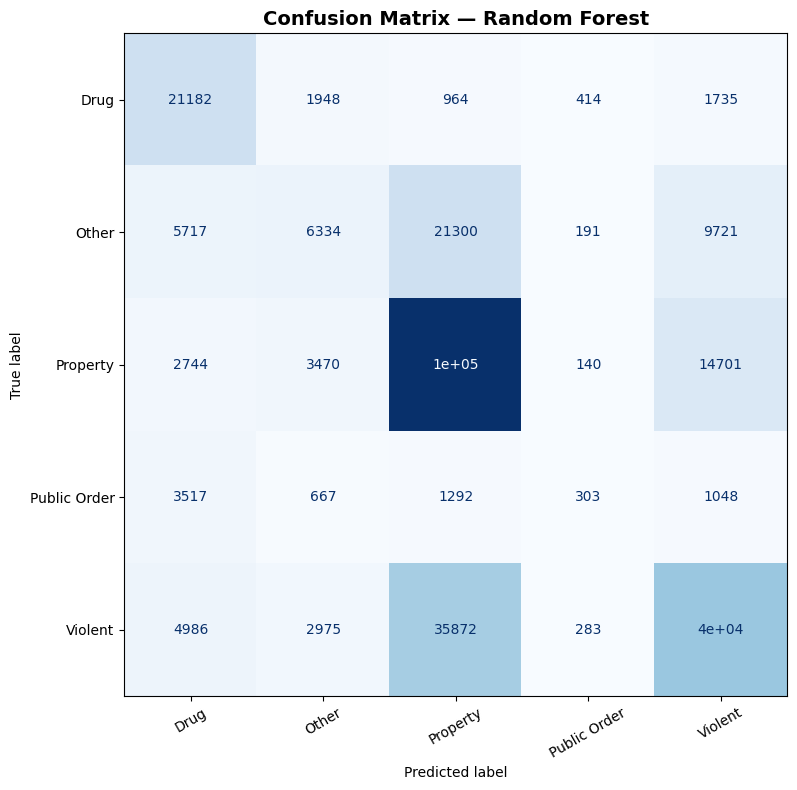

In [14]:
best_model_name = max(results, key=lambda m: results[m]['accuracy'])
best_preds = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, best_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/09_confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()

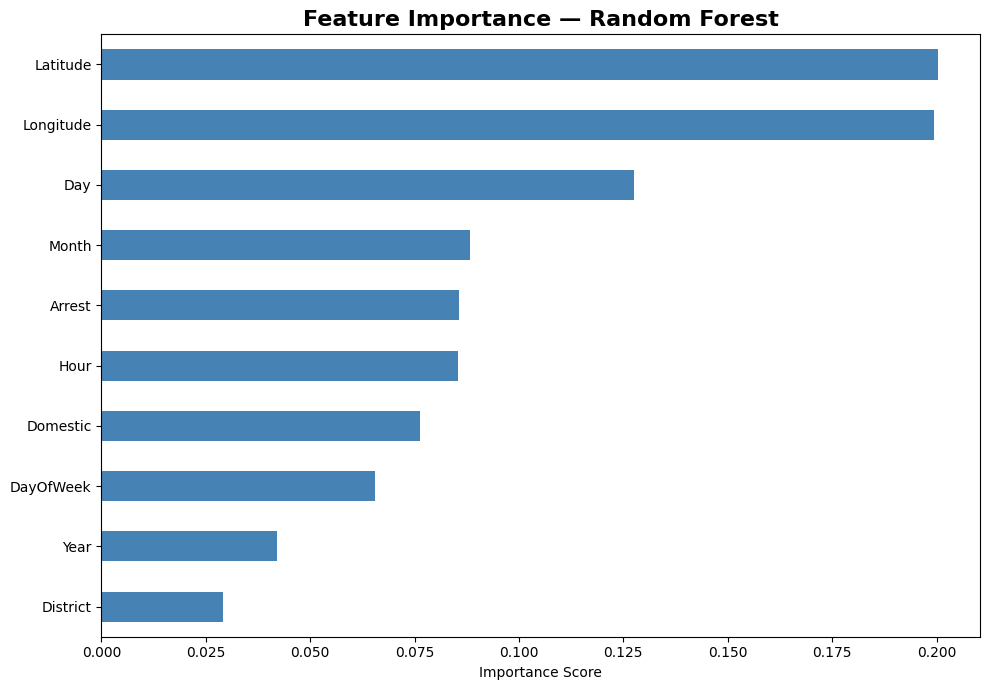

✅ Model saved!
✅ Feature importance chart saved!


In [15]:
# Save best model, scaler and label encoder
rf_model = results['Random Forest']['model']

pickle.dump(rf_model, open('/Users/prernamalhotra/CRIME/crime-analysis-prediction/models/best_model.pkl', 'wb'))
pickle.dump(scaler, open('/Users/prernamalhotra/CRIME/crime-analysis-prediction/models/scaler.pkl', 'wb'))
pickle.dump(le, open('/Users/prernamalhotra/CRIME/crime-analysis-prediction/models/label_encoder.pkl', 'wb'))
json.dump(feature_cols, open('/Users/prernamalhotra/CRIME/crime-analysis-prediction/models/feature_cols.json', 'w'))

# Feature importance chart
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/10_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model saved!")
print("✅ Feature importance chart saved!")

In [16]:
# ─── WEEK 2: XGBoost + SMOTE ──────────────────────────────────
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report
import pickle

print("Step 1: Applying SMOTE to fix class imbalance...")
print(f"Before SMOTE — class distribution:")
import pandas as pd
import numpy as np
counts = pd.Series(y_train).value_counts()
print(counts)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — class distribution:")
print(pd.Series(y_train_sm).value_counts())
print(f"Training size after SMOTE: {X_train_sm.shape[0]:,}")

Step 1: Applying SMOTE to fix class imbalance...
Before SMOTE — class distribution:
2    495164
4    335205
1    173054
0    104971
3     27310
Name: count, dtype: int64

After SMOTE — class distribution:
0    495164
2    495164
4    495164
1    495164
3    495164
Name: count, dtype: int64
Training size after SMOTE: 2,475,820


In [17]:
print("\nStep 2: Training XGBoost on balanced data...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_model.fit(X_train_sm, y_train_sm)
xgb_pred = xgb_model.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)

print(f"✅ XGBoost Accuracy: {xgb_acc*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))


Step 2: Training XGBoost on balanced data...
✅ XGBoost Accuracy: 58.49%

Classification Report:
              precision    recall  f1-score   support

        Drug       0.47      0.87      0.61     26243
       Other       0.42      0.07      0.12     43263
    Property       0.62      0.87      0.72    123792
Public Order       0.13      0.21      0.16      6827
     Violent       0.70      0.38      0.49     83802

    accuracy                           0.58    283927
   macro avg       0.47      0.48      0.42    283927
weighted avg       0.59      0.58      0.54    283927



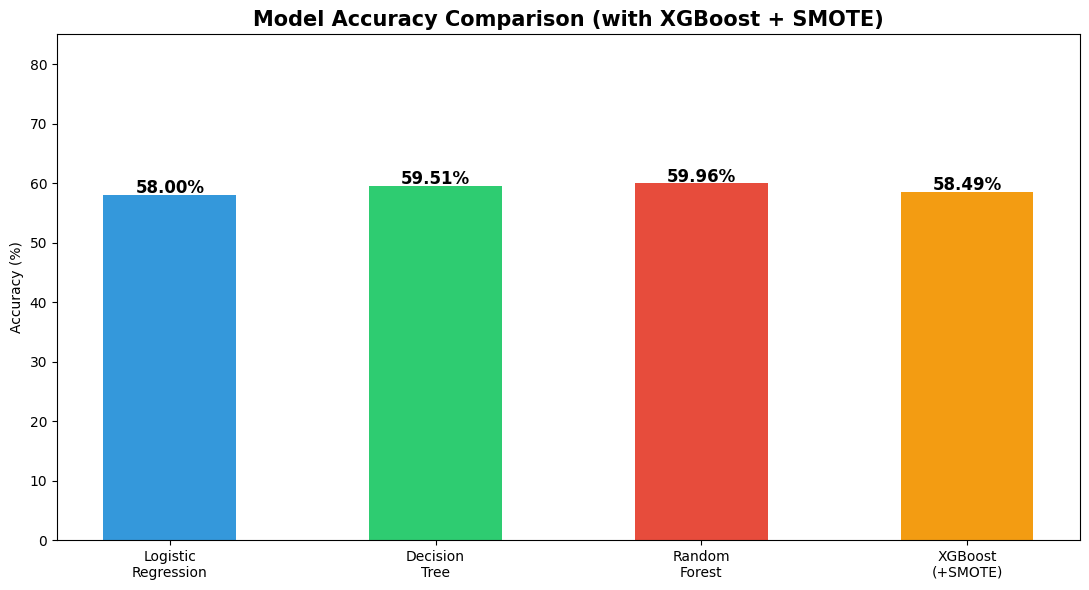

Chart saved!


In [18]:
import matplotlib.pyplot as plt

all_results = {
    'Logistic\nRegression': results['Logistic Regression']['accuracy'],
    'Decision\nTree':       results['Decision Tree']['accuracy'],
    'Random\nForest':       results['Random Forest']['accuracy'],
    'XGBoost\n(+SMOTE)':   xgb_acc
}

plt.figure(figsize=(11, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = plt.bar(all_results.keys(), [v*100 for v in all_results.values()],
               color=colors, width=0.5)

for bar, val in zip(bars, all_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Model Accuracy Comparison (with XGBoost + SMOTE)', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 85)
plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/12_model_comparison_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [19]:
# Save XGBoost as updated best model
pickle.dump(xgb_model, open('/Users/prernamalhotra/CRIME/crime-analysis-prediction/models/best_model.pkl', 'wb'))
print("✅ XGBoost saved as best_model.pkl")
print("✅ Streamlit app will now automatically use XGBoost for predictions!")

✅ XGBoost saved as best_model.pkl
✅ Streamlit app will now automatically use XGBoost for predictions!


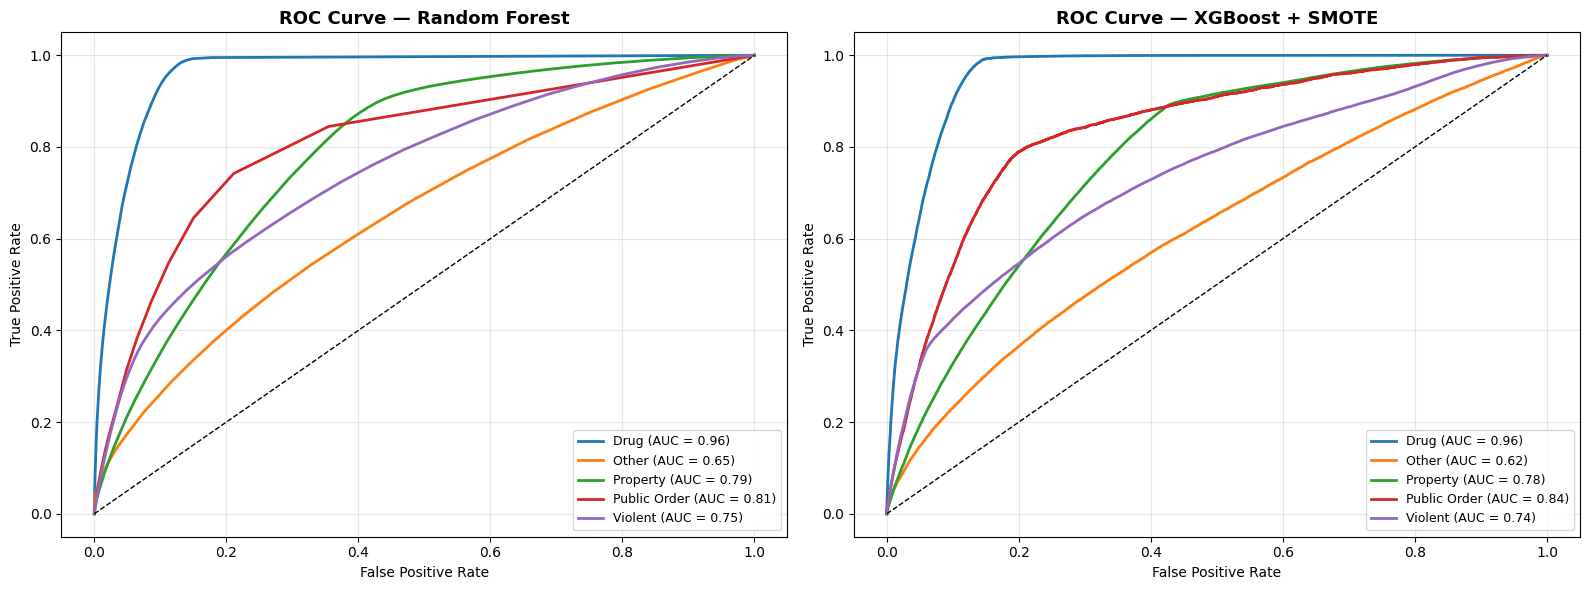

✅ ROC Curve saved!


In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize for multi-class ROC
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC for Random Forest
rf_proba = results['Random Forest']['model'].predict_proba(X_test)
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# ROC for XGBoost
xgb_proba = xgb_model.predict_proba(X_test)
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curve — XGBoost + SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/13_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC Curve saved!")

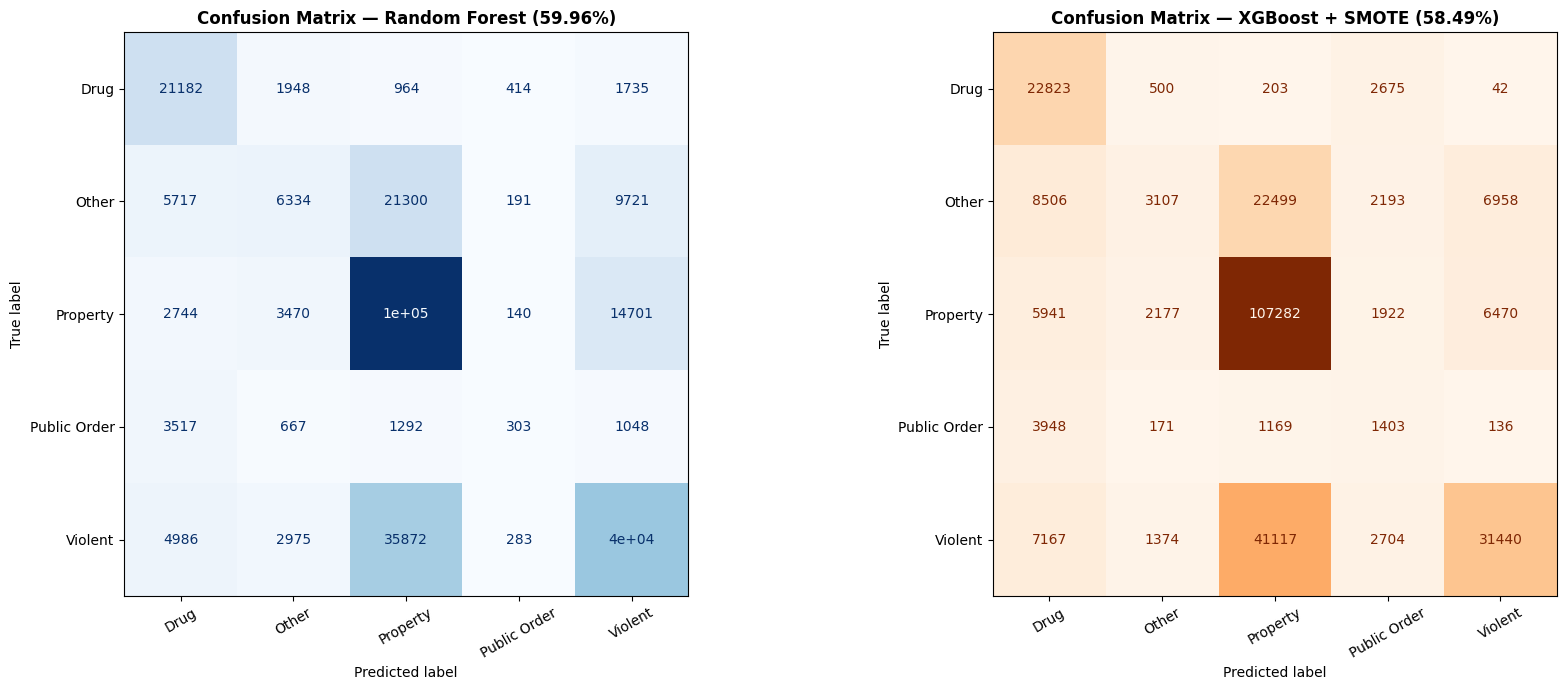

✅ Confusion matrix comparison saved!


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, results['Random Forest']['predictions'])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest (59.96%)',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp2.plot(cmap='Oranges', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — XGBoost + SMOTE (58.49%)',
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/Users/prernamalhotra/CRIME/crime-analysis-prediction/outputs/14_confusion_matrix_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix comparison saved!")

In [22]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost + SMOTE'],
    'Accuracy (%)': [58.00, 59.51, 59.96, 58.49],
    'SMOTE Applied': ['No', 'No', 'No', 'Yes'],
    'Best For': [
        'Baseline comparison',
        'Interpretability',
        'Overall accuracy ⭐ BEST',
        'Minority class recall'
    ],
    'Training Time': ['Fast', 'Fast', 'Medium', 'Slow']
})

print("=" * 65)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print("\n✅ Best Model: Random Forest — 59.96%")
print("✅ All models saved to /models/")
print("✅ All charts saved to /outputs/")
print("\n🎯 NOTEBOOK 3 FULLY COMPLETE — Ready for Final Presentation!")

         FINAL MODEL COMPARISON SUMMARY
              Model  Accuracy (%) SMOTE Applied                Best For Training Time
Logistic Regression         58.00            No     Baseline comparison          Fast
      Decision Tree         59.51            No        Interpretability          Fast
      Random Forest         59.96            No Overall accuracy ⭐ BEST        Medium
    XGBoost + SMOTE         58.49           Yes   Minority class recall          Slow

✅ Best Model: Random Forest — 59.96%
✅ All models saved to /models/
✅ All charts saved to /outputs/

🎯 NOTEBOOK 3 FULLY COMPLETE — Ready for Final Presentation!
